Using SVM to classify a situation under "fire" or "non fire" categories

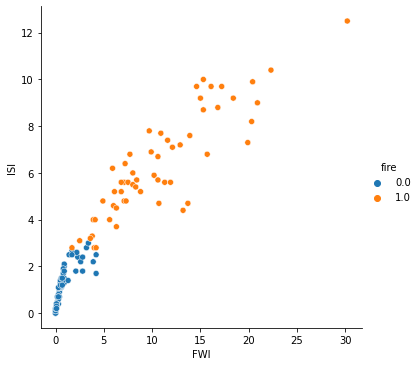

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open("Algerian_forest_fires_dataset_UPDATE.csv", "r") as file_input:
    with open("qw.csv", "w") as output:
        for line in file_input:
            if line.strip("\n") != "Bejaia Region Dataset ":
                output.write(line)



k=open("qw.csv","r")


df = pd.read_csv('qw.csv',delimiter=',')
df = df.dropna(axis=0)
df=df.drop(columns=['day','month','year'])
df=df.iloc[:122,:]

df[' RH']=df[' RH'].astype('float')
df[' Ws']=df[' Ws'].astype('float')
df['Rain ']=df['Rain '].astype('float')
df['FFMC']=df['FFMC'].astype('float')
df['DMC']=df['DMC'].astype('float')
df['DC']=df['DC'].astype('float')
df['ISI']=df['ISI'].astype('float')
df['BUI']=df['BUI'].astype('float')
df['Temperature']=df['Temperature'].astype('float')
df['FWI']=df['FWI'].astype('float')

independent_variables=[' RH',' Ws','Rain ','FFMC','DMC','DC','ISI','BUI','Temperature','FWI']
X=df[independent_variables]
#X=X.iloc[:122,:]

y=df[['Classes  ']]
y=y.iloc[0:122]

y=y.replace(to_replace =["fire   ","fire "],
                 value ="fire")
y=y.replace(to_replace =["not fire   ","not fire "],
                 value ="not fire")
y1=y



dummies = pd.get_dummies(y['Classes  '])
y = pd.concat([y, dummies], axis=1)
y=y.drop(columns=["Classes  "])
y=y.drop(columns=["not fire"])
y['fire']=y['fire'].astype('float')
frames=[X,y]
comb=pd.concat([X,y],axis=1)


#comb.head()

In [ ]:
comb.corr(method='pearson')


,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Temperature,FWI,fire
RH,1.000000,0.245774,0.329163,-0.653153,-0.347080,-0.314271,-0.586410,-0.338233,-0.660151,-0.476067,-0.377328
Ws,0.245774,1.000000,0.349321,-0.211069,0.039394,0.099231,-0.039266,0.062212,-0.228035,0.029637,-0.121408
Rain,0.329163,0.349321,1.000000,-0.573476,-0.265371,-0.283652,-0.366425,-0.271951,-0.486947,-0.292914,-0.334392
FFMC,-0.653153,-0.211069,-0.573476,1.000000,0.608512,0.575221,0.790086,0.600707,0.748423,0.675553,0.743637
DMC,-0.347080,0.039394,-0.265371,0.608512,1.000000,0.962193,0.750098,0.995551,0.541489,0.901759,0.616951
DC,-0.314271,0.099231,-0.283652,0.575221,0.962193,1.000000,0.717591,0.982554,0.532838,0.869911,0.588464
ISI,-0.586410,-0.039266,-0.366425,0.790086,0.750098,0.717591,1.000000,0.746761,0.663871,0.944062,0.831796
BUI,-0.338233,0.062212,-0.271951,0.600707,0.995551,0.982554,0.746761,1.000000,0.542210,0.900417,0.612576
Temperature,-0.660151,-0.228035,-0.486947,0.748423,0.541489,0.532838,0.663871,0.542210,1.000000,0.608367,0.497810
FWI,-0.476067,0.029637,-0.292914,0.675553,0.901759,0.869911,0.944062,0.900417,0.608367,1.000000,0.759758


In [ ]:
X=X[['FWI','ISI']]

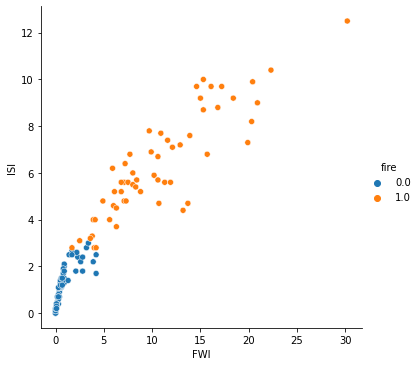

In [ ]:
import seaborn as sns

sns.relplot(x="FWI", y="ISI", hue="fire",data=comb);

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn import svm
from sklearn.svm import LinearSVC

#Create a svm Classifier
#clf = OneVsRestClassifier(LinearSVC(max_iter=1200000))
clf= svm.SVC(kernel='linear', C=1)
#clf=svm.SVC(kernel='poly', degree=3, gamma='auto')
#clf=svm.SVC(kernel='rbf', gamma=0.7)

clf.fit(X_train, y_train.values.ravel())

#Predict the response for test dataset
y_pred = clf.predict(X_test)






In [ ]:
from sklearn import metrics

# Model Accuracy: how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.96


In [ ]:
print("Precision:",metrics.precision_score(y_test, y_pred,average='micro'))

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",metrics.recall_score(y_test, y_pred,average='micro'))

Precision: 0.96
Recall: 0.96


<function matplotlib.pyplot.show>

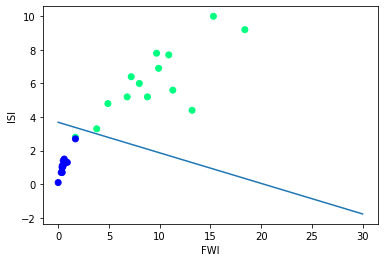

In [ ]:
ax=plt.gca()


ax.scatter(X_test['FWI'], X_test['ISI'], c=y_test['fire'], cmap='winter',marker='o')
plt.xlabel('FWI')
plt.ylabel('ISI')


w= clf.coef_[0]
a= -w[0]/w[1]
xx= np.linspace(0,30)
yy= a* xx - (clf.intercept_[0]/w[1])
plt.plot(xx,yy)
plt.show

Using Random Forest Algorithm to predict Fire Weather Index

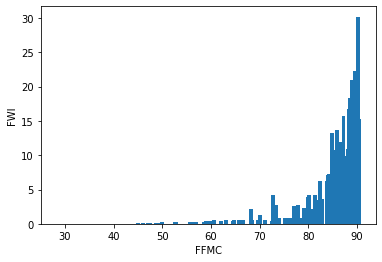

Text(0, 0.5, 'FWI')

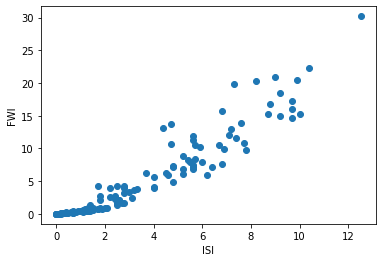

In [ ]:

df1 = pd.read_csv('qw.csv',delimiter=',')
df1 = df1.dropna(axis=0)
list(df.columns)

independent_variables=['FFMC','DMC','DC','BUI','Temperature','ISI','Classes  ']
X1=df[independent_variables]
X1=X1.iloc[:122,:]
y1=df1[['FWI']]
y1=y1.iloc[0:122]


#X=df.iloc[:122,:-1]
#y=df.iloc[:122,-1:]

#y=y.replace(to_replace =["fire   ","fire "],
            #     value ="fire")
#y=y.replace(to_replace =["not fire   ","not fire "],
             #    value ="not fire")


X1=X1.replace(to_replace =["fire   ","fire "],
                 value ="fire")
X1=X1.replace(to_replace =["not fire   ","not fire "],
                 value ="not fire")

dummies = pd.get_dummies(X1['Classes  '])
X1 = pd.concat([X1, dummies], axis=1)
X1=X1.drop(columns=["Classes  "])
X1=X1.drop(columns=['not fire'])
X1_numpy = np.array(X1)
X1_numpy=X1_numpy.astype('float')
y1_numpy=np.array(y1)
y1_numpy=y1_numpy.astype('float')
qw1=X1["FFMC"]
qw1=(qw1.astype('float'))
yy1=(y1["FWI"].astype('float'))
plt.bar(qw1, yy1)

# naming the x axis
plt.xlabel('FFMC')
# naming the y axis
plt.ylabel('FWI')

plt.show()


plt.scatter(X1['ISI'],yy1)
plt.xlabel('ISI')
plt.ylabel('FWI')

In [ ]:
from sklearn.model_selection import train_test_split
X1_train, X1_test, y1_train, y1_test = train_test_split(X1_numpy, y1_numpy, test_size=0.2, random_state=1)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV


num_trees=100
dt_model = RandomForestRegressor(random_state=1, max_depth= 14, max_samples=50, max_features=7, n_estimators=num_trees)

#Fit RandomForestRegressor model
dt_model.fit(X1_train, y1_train.ravel())


"""
param_grid = {
    "n_estimators": [100,200, 300, 400],
    "max_depth": [8,10,12,14],
    "max_samples": [50, 100,200],
    "max_features": [4, 5, 6, 7, 8],
    "criterion": ["gini", "entropy"]
}

num_trees=5

rf_model = RandomForestClassifier()

# set gridsearch
#njob=-1 means use all the cores for parallel processing
gridSearchCV = GridSearchCV(
    estimator=rf_model, param_grid=param_grid, cv=4, verbose=2, n_jobs=-1)

gridSearchCVResults = gridSearchCV.fit(X_train, y_train)
print(f"Best score = {gridSearchCVResults.best_score_}, Best Hyperparameters ={gridSearchCVResults.best_params_}")

"""
#Fit RandomForestRegressor model
dt_model.fit(X1_train, y1_train.ravel())

pred1=dt_model.predict(X1_test)


print("Making predictions for the following in train set:")
predicted_values=dt_model.predict(X1_train[0:10,:])
true_values=y1_train[0:10]
print("True values are ",true_values)
print("The predicted values are", predicted_values)
print("Diff", (predicted_values-true_values))


print("Making predictions for the following in testing set:")
predicted_values=dt_model.predict(X1_test[0:10,:])
true_values=y1_test[0:10]
print("True values are ",true_values)
print("The predicted values are", predicted_values)
print("Diff", predicted_values-true_values)

# Average training error
dfTrain=y1_train-dt_model.predict(X1_train)
print("Average Train error ", np.absolute(dfTrain).mean())

# Average val error
#dfVal=y_val-dt_model.predict(X_val)
#print("Average val error ", dfVal.abs().mean())
#print("Average val error ", np.absolute(dfVal).mean())

# Average test error
dfTest=y1_test-pred1
print("Average test error ", np.absolute(dfTest).mean())



Making predictions for the following in train set:
True values are  [[ 7.3]
 [ 6.8]
 [ 9.9]
 [19.9]
 [ 0.6]
 [14.6]
 [ 3.4]
 [ 0.2]
 [15.3]
 [ 1.3]]
The predicted values are [ 7.713  7.15   9.515 16.813  0.703 14.083  3.359  0.263 14.756  1.651]
Diff [[  0.413  -0.15    2.215   9.513  -6.597   6.783  -3.941  -7.037   7.456
   -5.649]
 [  0.913   0.35    2.715  10.013  -6.097   7.283  -3.441  -6.537   7.956
   -5.149]
 [ -2.187  -2.75   -0.385   6.913  -9.197   4.183  -6.541  -9.637   4.856
   -8.249]
 [-12.187 -12.75  -10.385  -3.087 -19.197  -5.817 -16.541 -19.637  -5.144
  -18.249]
 [  7.113   6.55    8.915  16.213   0.103  13.483   2.759  -0.337  14.156
    1.051]
 [ -6.887  -7.45   -5.085   2.213 -13.897  -0.517 -11.241 -14.337   0.156
  -12.949]
 [  4.313   3.75    6.115  13.413  -2.697  10.683  -0.041  -3.137  11.356
   -1.749]
 [  7.513   6.95    9.315  16.613   0.503  13.883   3.159   0.063  14.556
    1.451]
 [ -7.587  -8.15   -5.785   1.513 -14.597  -1.217 -11.941 -15.037  -0